In [2]:
#loading dataset
import pandas as pd
df=pd.read_csv("/content/diabetes.csv")
print(df.shape)
df.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
#data inspection
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [4]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


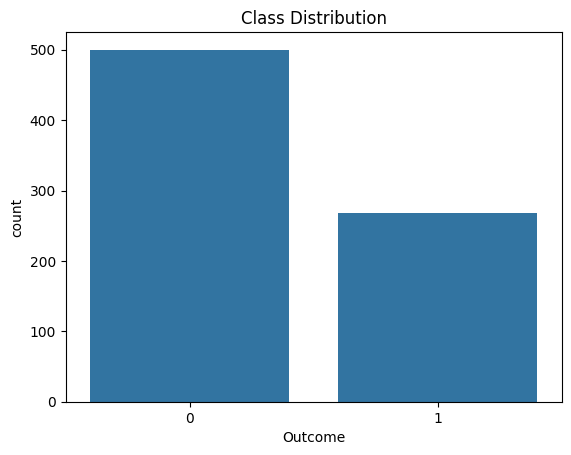

Outcome
0    500
1    268
Name: count, dtype: int64


In [6]:
#class distribution analysis
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x="Outcome",data=df)
plt.title("Class Distribution")
plt.show()
print(df['Outcome'].value_counts())

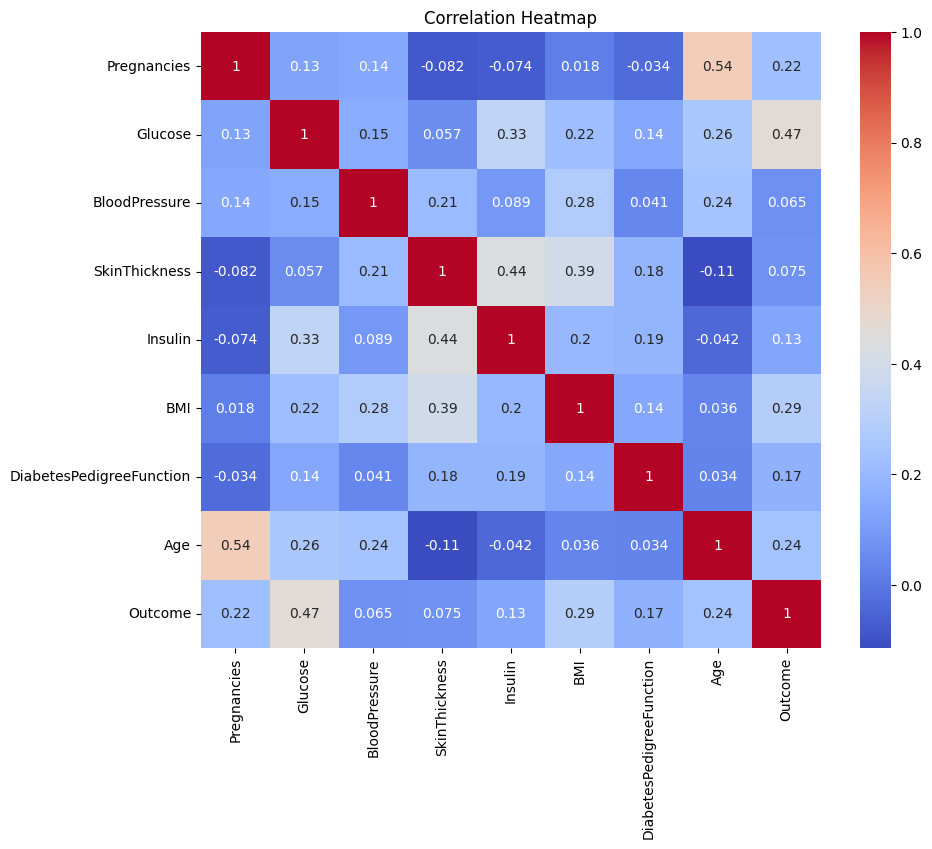

In [7]:
#correlation analysis
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [9]:
#EDA
sns.set_style("whitegrid")

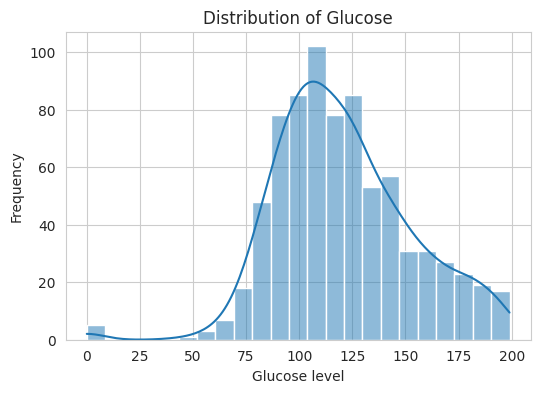

In [10]:
#glucose plots
plt.figure(figsize=(6,4))
sns.histplot(df['Glucose'],kde=True)
plt.title("Distribution of Glucose")
plt.xlabel("Glucose level")
plt.ylabel("Frequency")
plt.show()

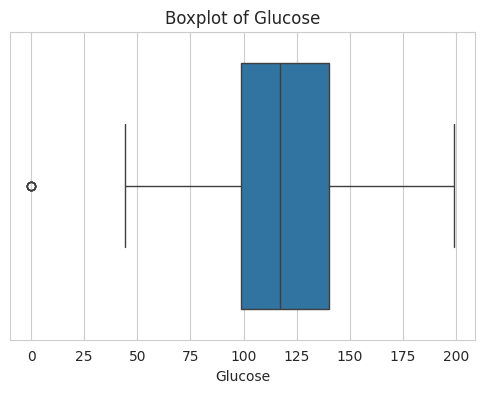

In [11]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Glucose'])
plt.title("Boxplot of Glucose")
plt.show()

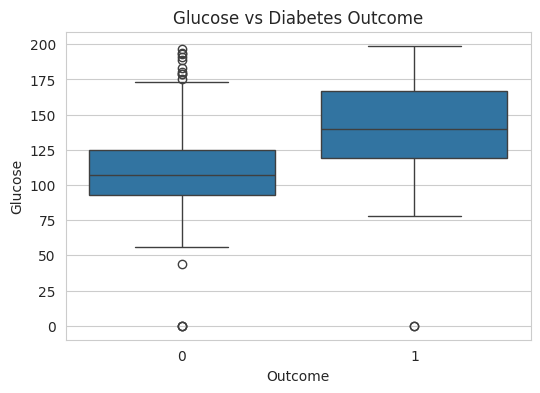

In [12]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Outcome', y='Glucose', data=df)
plt.title("Glucose vs Diabetes Outcome")
plt.show()

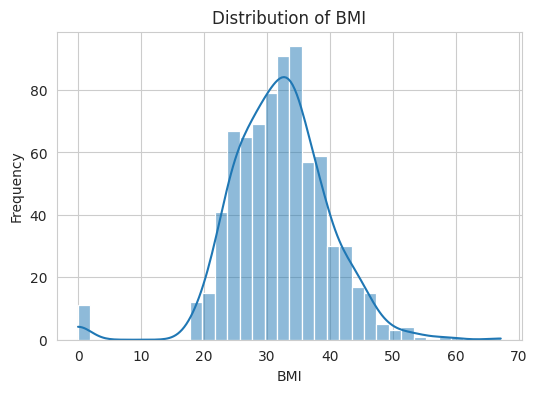

In [13]:
#BMI Plots
plt.figure(figsize=(6,4))
sns.histplot(df['BMI'], kde=True)
plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

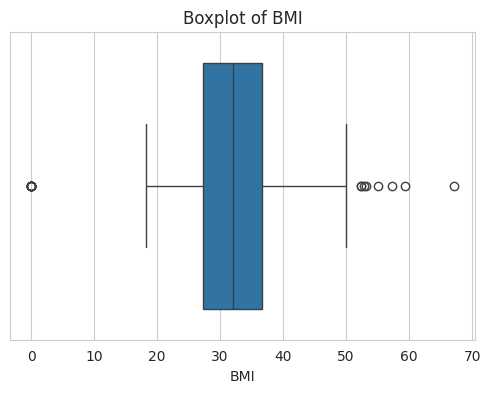

In [14]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['BMI'])
plt.title("Boxplot of BMI")
plt.show()

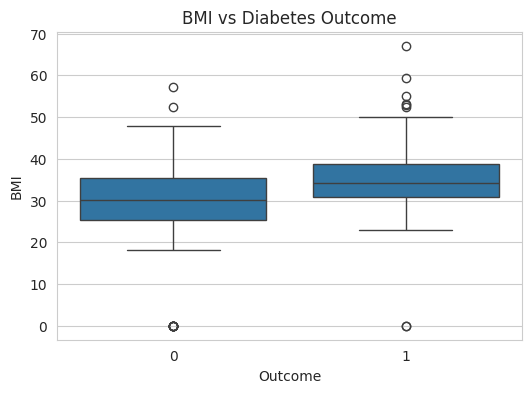

In [15]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Outcome', y='BMI', data=df)
plt.title("BMI vs Diabetes Outcome")
plt.show()

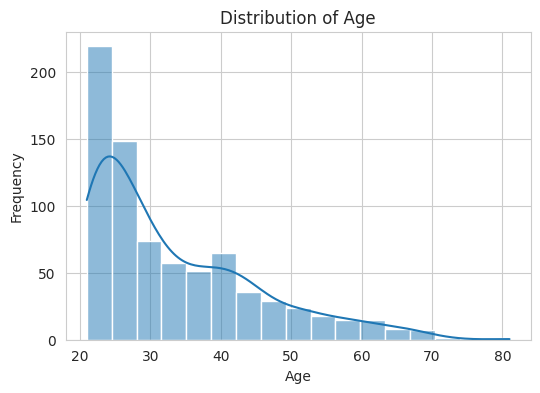

In [16]:
#Age plots
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

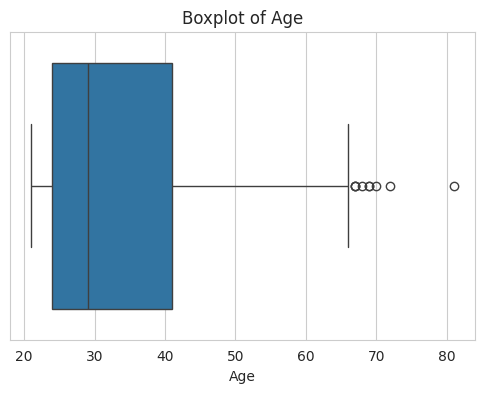

In [17]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Age'])
plt.title("Boxplot of Age")
plt.show()

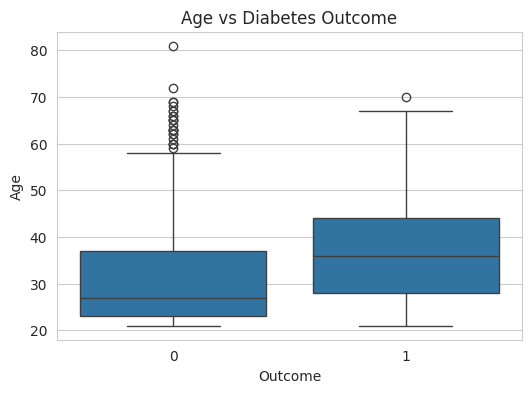

In [18]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Outcome', y='Age', data=df)
plt.title("Age vs Diabetes Outcome")
plt.show()

In [19]:
#phase2 _ identify invalid zero values
cols = ['Glucose','BloodPressure', 'SkinThickness','Insulin','BMI']
for col in cols:
  print(col,(df[col]==0).sum())

Glucose 5
BloodPressure 35
SkinThickness 227
Insulin 374
BMI 11


In [20]:
#replace zeroes with median
for col in cols:
  df[col]=df[col].replace(0,df[col].median())

In [21]:
for col in cols:
  print(col,(df[col]==0).sum())

Glucose 0
BloodPressure 0
SkinThickness 0
Insulin 0
BMI 0


In [25]:
#feature engineering bmi category
def bmi_category(bmi):
  if bmi < 18.5:
    return "Underweight"
  elif bmi < 25:
    return "Normal"
  elif bmi < 30:
    return "Overweight"
  else:
    return "Obese"
  df['BMI_Category']=df['BMI'].apply(bmi_category)

In [26]:
#age category
def age_group(age):
  if age < 30:
    return "Young"
  elif age < 50:
    return "Middle"
  else :
    return "Senior"
  df['Age_Group']=df['Age'].apply(age_group)

In [29]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Glucose_BMI_Ratio
0,6,148,72,35,30.5,33.6,0.627,50,1,4.404762
1,1,85,66,29,30.5,26.6,0.351,31,0,3.195489
2,8,183,64,23,30.5,23.3,0.672,32,1,7.854077
3,1,89,66,23,94.0,28.1,0.167,21,0,3.167260
4,0,137,40,35,168.0,43.1,2.288,33,1,3.178654
...,...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180.0,32.9,0.171,63,0,3.069909
764,2,122,70,27,30.5,36.8,0.340,27,0,3.315217
765,5,121,72,23,112.0,26.2,0.245,30,0,4.618321
766,1,126,60,23,30.5,30.1,0.349,47,1,4.186047


In [27]:
#glucose BMI ratio
df['Glucose_BMI_Ratio']=df['Glucose']/df['BMI']

In [30]:
#encode categorical features
df=pd.get_dummies(df,columns=['BMI','Age'],drop_first=True)

In [31]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,DiabetesPedigreeFunction,Outcome,Glucose_BMI_Ratio,BMI_18.4,BMI_19.1,...,Age_63,Age_64,Age_65,Age_66,Age_67,Age_68,Age_69,Age_70,Age_72,Age_81
0,6,148,72,35,30.5,0.627,1,4.404762,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1,85,66,29,30.5,0.351,0,3.195489,False,False,...,False,False,False,False,False,False,False,False,False,False
2,8,183,64,23,30.5,0.672,1,7.854077,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1,89,66,23,94.0,0.167,0,3.167260,False,False,...,False,False,False,False,False,False,False,False,False,False
4,0,137,40,35,168.0,2.288,1,3.178654,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
#define X and Y
X= df[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin']]
y = df['Outcome']

In [ ]:
#train and test
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin']]
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

In [37]:
#feature scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [38]:
#phase3 import required models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [39]:
#logistic Regression
lr=LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr=lr.predict(X_test)
print("Logistic Regression Accuracy:",
  accuracy_score(y_test,y_pred_lr))
print(confusion_matrix(y_test,y_pred_lr))
print(classification_report(y_test,y_pred_lr))


Logistic Regression Accuracy: 0.7142857142857143
[[81 18]
 [26 29]]
              precision    recall  f1-score   support

           0       0.76      0.82      0.79        99
           1       0.62      0.53      0.57        55

    accuracy                           0.71       154
   macro avg       0.69      0.67      0.68       154
weighted avg       0.71      0.71      0.71       154



In [41]:
#Random Forest
rf=RandomForestClassifier(random_state=42)
rf.fit(X_train,y_train)

y_pred_rf=rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test,y_pred_rf))
print(confusion_matrix(y_test,y_pred_rf))
print(classification_report(y_test,y_pred_rf))

Random Forest Accuracy: 0.7532467532467533
[[87 12]
 [26 29]]
              precision    recall  f1-score   support

           0       0.77      0.88      0.82        99
           1       0.71      0.53      0.60        55

    accuracy                           0.75       154
   macro avg       0.74      0.70      0.71       154
weighted avg       0.75      0.75      0.74       154



In [42]:
#svm
svm=SVC()
svm.fit(X_train,y_train)
y_pred_svm=svm.predict(X_test)
print("SVM Accuracy:",
    accuracy_score(y_test,y_pred_svm))
print(confusion_matrix(y_test,y_pred_svm))
print(classification_report(y_test,y_pred_svm))


SVM Accuracy: 0.6688311688311688
[[83 16]
 [35 20]]
              precision    recall  f1-score   support

           0       0.70      0.84      0.76        99
           1       0.56      0.36      0.44        55

    accuracy                           0.67       154
   macro avg       0.63      0.60      0.60       154
weighted avg       0.65      0.67      0.65       154



In [44]:
#compare all models
results={
    "Logistic Regression": accuracy_score(y_test,y_pred_lr),
    "Random Forest": accuracy_score(y_test,y_pred_rf),
    "SVM": accuracy_score(y_test,y_pred_svm)
}
for model, acc in results.items():
    print(model,":",acc)


Logistic Regression : 0.7142857142857143
Random Forest : 0.7532467532467533
SVM : 0.6688311688311688


In [47]:
#phase4 handling class imbalance SMOTE
!pip install imbalanced-learn



In [48]:
#import SMOTE
from imblearn.over_sampling import SMOTE

In [50]:
#apply smote only on training data
smote=SMOTE(random_state=42)
X_train_smote,y_train_smote=smote.fit_resample(X_train,y_train)

In [51]:
#check new class distribution
print("Before SMOTE:",y_train.value_counts())
print("After SMOTE:",y_train_smote.value_counts())

Before SMOTE: Outcome
0    401
1    213
Name: count, dtype: int64
After SMOTE: Outcome
0    401
1    401
Name: count, dtype: int64


In [52]:
#Logistic_Regression
lr_sm = LogisticRegression()
lr_sm.fit(X_train_smote, y_train_smote)

y_pred_lr_sm = lr_sm.predict(X_test)

print("Logistic Regression (SMOTE) Accuracy:",
      accuracy_score(y_test, y_pred_lr_sm))

print(confusion_matrix(y_test, y_pred_lr_sm))
print(classification_report(y_test, y_pred_lr_sm))

Logistic Regression (SMOTE) Accuracy: 0.7012987012987013
[[78 21]
 [25 30]]
              precision    recall  f1-score   support

           0       0.76      0.79      0.77        99
           1       0.59      0.55      0.57        55

    accuracy                           0.70       154
   macro avg       0.67      0.67      0.67       154
weighted avg       0.70      0.70      0.70       154



In [53]:
#Random Forest
rf_sm = RandomForestClassifier(random_state=42)
rf_sm.fit(X_train_smote, y_train_smote)

y_pred_rf_sm = rf_sm.predict(X_test)

print("Random Forest (SMOTE) Accuracy:",
      accuracy_score(y_test, y_pred_rf_sm))

print(confusion_matrix(y_test, y_pred_rf_sm))
print(classification_report(y_test, y_pred_rf_sm))

Random Forest (SMOTE) Accuracy: 0.7597402597402597
[[83 16]
 [21 34]]
              precision    recall  f1-score   support

           0       0.80      0.84      0.82        99
           1       0.68      0.62      0.65        55

    accuracy                           0.76       154
   macro avg       0.74      0.73      0.73       154
weighted avg       0.76      0.76      0.76       154



In [54]:
#SVM
svm_sm = SVC()
svm_sm.fit(X_train_smote, y_train_smote)

y_pred_svm_sm = svm_sm.predict(X_test)

print("SVM (SMOTE) Accuracy:",
      accuracy_score(y_test, y_pred_svm_sm))

print(confusion_matrix(y_test, y_pred_svm_sm))
print(classification_report(y_test, y_pred_svm_sm))

SVM (SMOTE) Accuracy: 0.7142857142857143
[[80 19]
 [25 30]]
              precision    recall  f1-score   support

           0       0.76      0.81      0.78        99
           1       0.61      0.55      0.58        55

    accuracy                           0.71       154
   macro avg       0.69      0.68      0.68       154
weighted avg       0.71      0.71      0.71       154



In [55]:
#phase5 ensemble model and feature importance
from sklearn.ensemble import VotingClassifier

In [56]:
ensemble_model=VotingClassifier(
    estimators=[
      ('lr',LogisticRegression()),
      ('rf',RandomForestClassifier(random_state=42)),
      ('svm',SVC(probability=True))
    ],
    voting='soft'
)
ensemble_model.fit(X_train_smote,y_train_smote)
y_pred_ensemble=ensemble_model.predict(X_test)

In [57]:
#evaluate ensemble model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Ensemble Accuracy:",
      accuracy_score(y_test,y_pred_ensemble))
print(confusion_matrix(y_test,y_pred_ensemble))
print(classification_report(y_test,y_pred_ensemble))


Ensemble Accuracy: 0.7077922077922078
[[79 20]
 [25 30]]
              precision    recall  f1-score   support

           0       0.76      0.80      0.78        99
           1       0.60      0.55      0.57        55

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.70      0.71      0.70       154



In [58]:
#extract feature importance
rf_final = RandomForestClassifier(random_state=42)
rf_final.fit(X_train_smote, y_train_smote)

importances = rf_final.feature_importances_

feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance_df.head(10)

,Feature,Importance
1,Glucose,0.175666
5,DiabetesPedigreeFunction,0.073880
6,Glucose_BMI_Ratio,0.071362
2,BloodPressure,0.062984
0,Pregnancies,0.062297
3,SkinThickness,0.058776
4,Insulin,0.050352
114,BMI_32.0,0.022535
112,BMI_31.6,0.022221
253,Age_22,0.017825


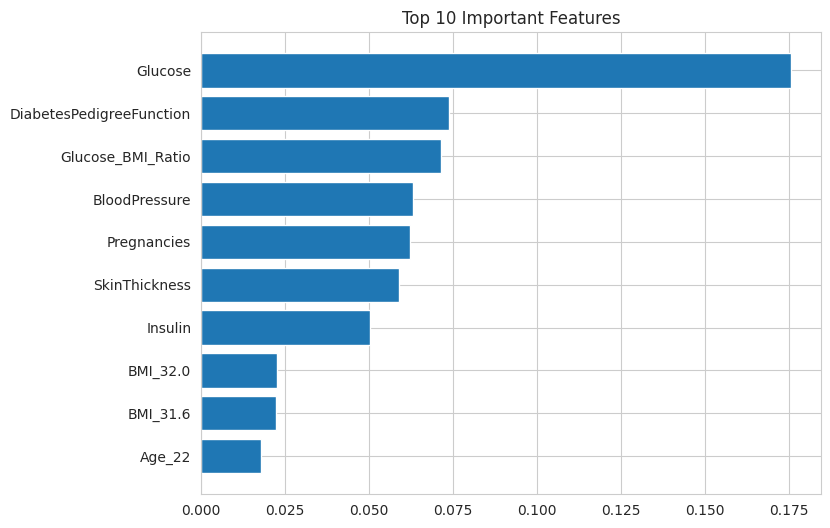

In [59]:
#plot feature importance
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.barh(feature_importance_df['Feature'][:10],
         feature_importance_df['Importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()